# 🔥 Prediksi Kalori yang Terbakar Selama Aktivitas Fisik

## Problem Definition
**Tujuan:** Membangun model machine learning untuk memprediksi jumlah kalori yang terbakar selama aktivitas fisik secara akurat.

**Model yang Digunakan:**
- Linear Regression (Baseline)
- Ridge Regression (Regularized Linear Model)
- Random Forest Regression (Ensemble Model)

**Fitur Input:**
- Age (Usia)
- Height (Tinggi Badan)
- Weight (Berat Badan)
- Duration (Durasi Olahraga)
- Heart_Rate (Detak Jantung)
- Body_Temp (Suhu Tubuh)

**Target Variable:** Calories (Jumlah Kalori Terbakar)

## Metodologi
1. Data Collection dari Kaggle
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Data Splitting (3 skenario: 70:30, 80:20, 90:10)
5. 10-Fold Cross-Validation
6. Hyperparameter Tuning
7. Evaluasi Model (MSE, RMSE, MAE, R²)
8. Pemilihan Model Terbaik untuk Deploy

## 1. Import Libraries

Mengimport semua library yang diperlukan untuk analisis data, visualisasi, preprocessing, modeling, dan evaluasi.

In [1]:
# Library untuk data manipulation
import pandas as pd
import numpy as np
import os

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk download dataset dari Kaggle
import kagglehub

# Library untuk preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Library untuk modeling
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Library untuk save model
import joblib

# Menghilangkan warning
import warnings
warnings.filterwarnings('ignore')

# Setting style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Semua library berhasil diimport")

c:\Users\ihram\Documents\Iamfolder\project\Machine Learning\Regresi\calories\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Semua library berhasil diimport


## 2. Data Collection

Mengunduh dataset dari Kaggle dengan sumber: `kushagrakinjawadekar/calories-burned-predicition`

Dataset ini terdiri dari dua file:
- `calories.csv`: Berisi data kalori yang terbakar
- `exercise.csv`: Berisi data informasi latihan dan profil pengguna

In [2]:
# Download dataset dari Kaggle
print("Mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("kushagrakinjawadekar/calories-burned-predicition")
print(f"✓ Dataset berhasil diunduh ke: {path}")

Mengunduh dataset dari Kaggle...
✓ Dataset berhasil diunduh ke: C:\Users\ihram\.cache\kagglehub\datasets\kushagrakinjawadekar\calories-burned-predicition\versions\1


## 3. Load dan Merge Dataset

Membaca kedua file CSV dan menggabungkannya berdasarkan `User_ID` untuk mendapatkan dataset lengkap.

In [3]:
# Load kedua dataset
calories_df = pd.read_csv(os.path.join(path, "calories.csv"))
exercise_df = pd.read_csv(os.path.join(path, "exercise.csv"))

print("=" * 60)
print("DATASET CALORIES")
print("=" * 60)
print(f"Shape: {calories_df.shape}")
print(calories_df.head())

print("\n" + "=" * 60)
print("DATASET EXERCISE")
print("=" * 60)
print(f"Shape: {exercise_df.shape}")
print(exercise_df.head())

DATASET CALORIES
Shape: (15000, 2)
    User_ID  Calories
0  14733363     231.0
1  14861698      66.0
2  11179863      26.0
3  16180408      71.0
4  17771927      35.0

DATASET EXERCISE
Shape: (15000, 8)
    User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8


In [4]:
# Merge kedua dataset berdasarkan User_ID
df = pd.merge(calories_df, exercise_df, on='User_ID', how='inner')

print("=" * 60)
print("DATASET GABUNGAN (MERGED)")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nKolom: {df.columns.tolist()}")
print("\n5 Baris Pertama:")
df.head()

DATASET GABUNGAN (MERGED)
Shape: (15000, 9)

Kolom: ['User_ID', 'Calories', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

5 Baris Pertama:


,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


## 4. Exploratory Data Analysis (EDA)

### 4.1 Inspeksi Awal Data

Melakukan inspeksi awal untuk memahami struktur data, tipe data, dan informasi dasar lainnya.

In [5]:
# Informasi umum dataset
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("CEK MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Calories    15000 non-null  float64
 2   Gender      15000 non-null  object 
 3   Age         15000 non-null  int64  
 4   Height      15000 non-null  float64
 5   Weight      15000 non-null  float64
 6   Duration    15000 non-null  float64
 7   Heart_Rate  15000 non-null  float64
 8   Body_Temp   15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB

CEK MISSING VALUES
            Missing Count  Percentage (%)
User_ID                 0             0.0
Calories                0             0.0
Gender                  0             0.0
Age                     0             0.0
Height                  0             0.0
Weight                  0             0.0
Duration                0             0.0
Heart

### 4.2 Statistik Deskriptif

Menampilkan ringkasan statistik untuk memahami distribusi data (mean, median, std dev, min, max).

In [6]:
# Statistik deskriptif
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df.describe()

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF (VARIABEL KATEGORIK)")
print("=" * 60)
df.describe(include=['object'])

STATISTIK DESKRIPTIF

STATISTIK DESKRIPTIF (VARIABEL KATEGORIK)


,Gender
count,15000
unique,2
top,female
freq,7553


### 4.3 Visualisasi Distribusi Data

Histogram dan boxplot untuk melihat distribusi setiap fitur numerik dan mendeteksi outlier secara visual.

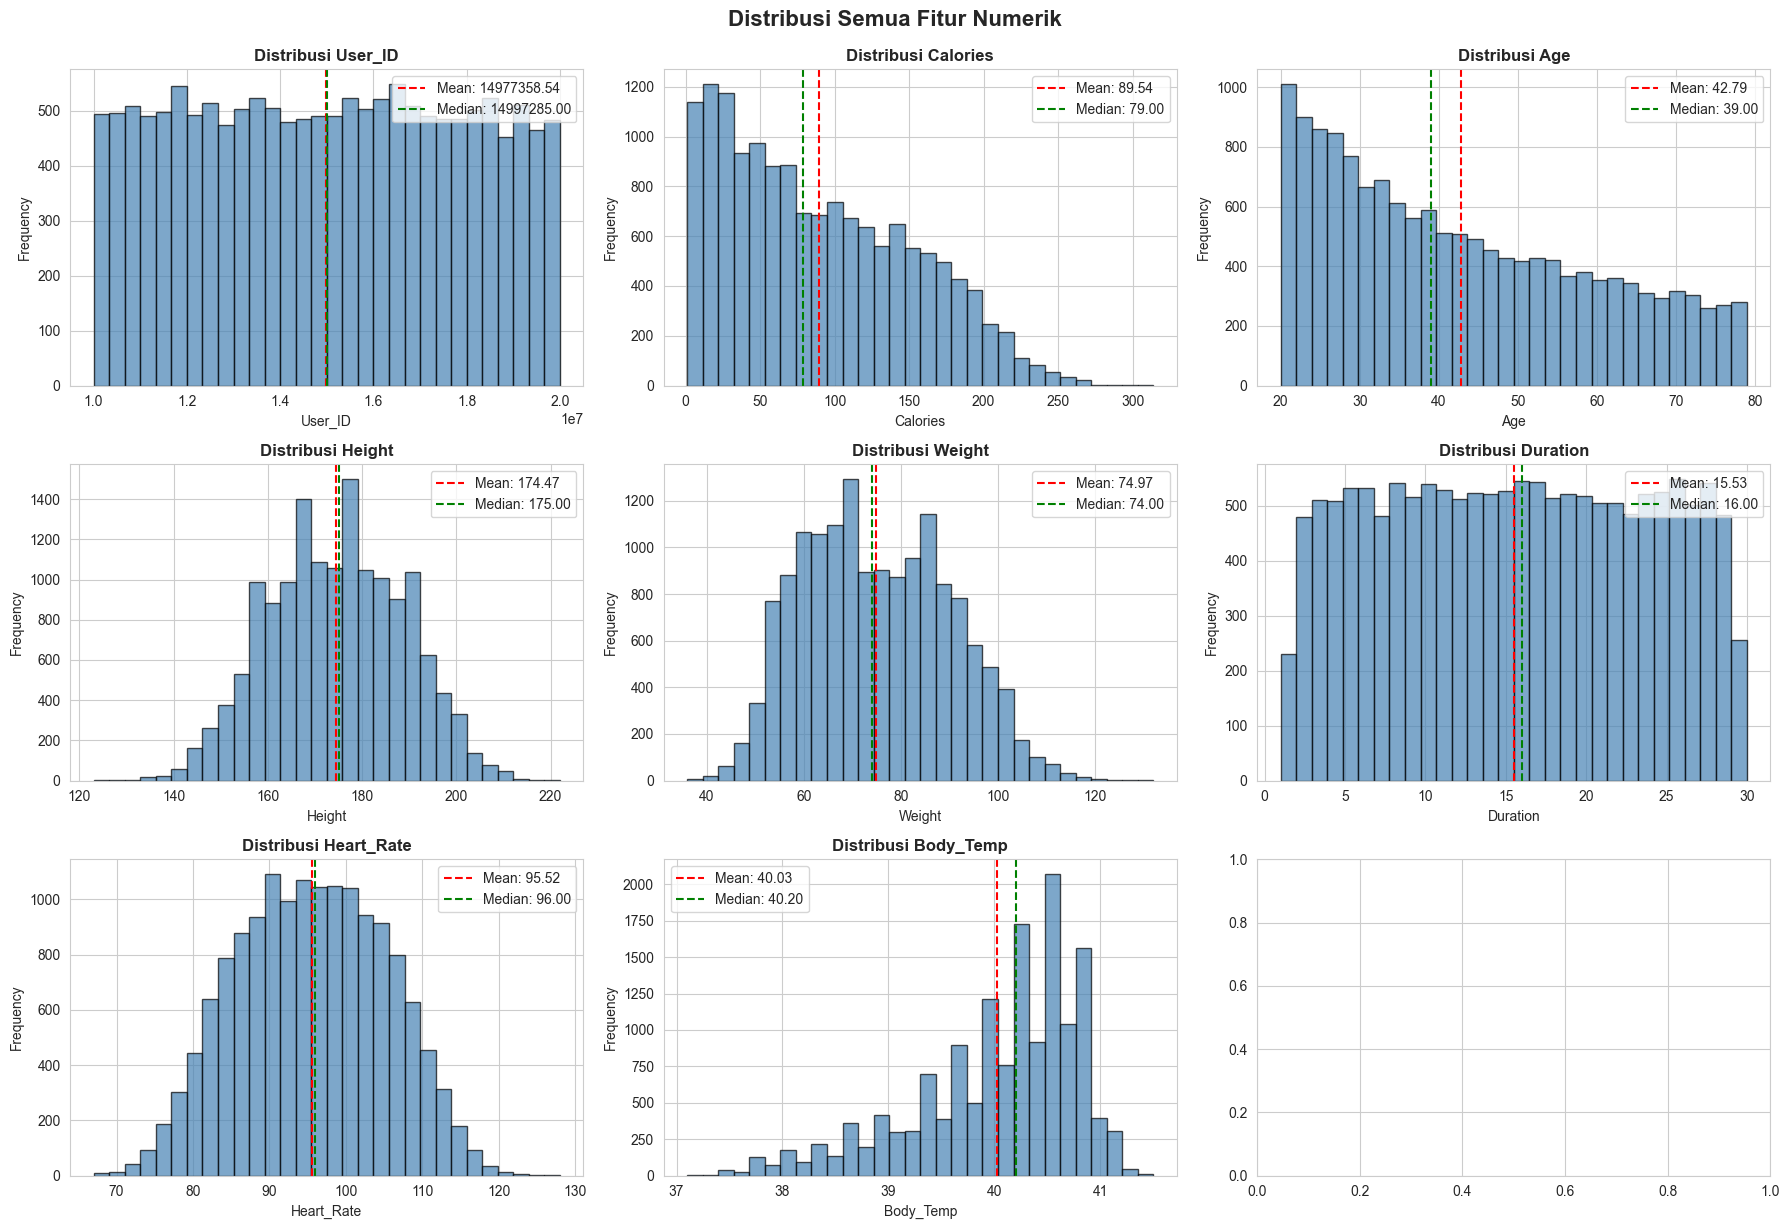

✓ Histogram menunjukkan distribusi data untuk setiap fitur


In [7]:
# Visualisasi distribusi semua fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.suptitle('Distribusi Semua Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✓ Histogram menunjukkan distribusi data untuk setiap fitur")

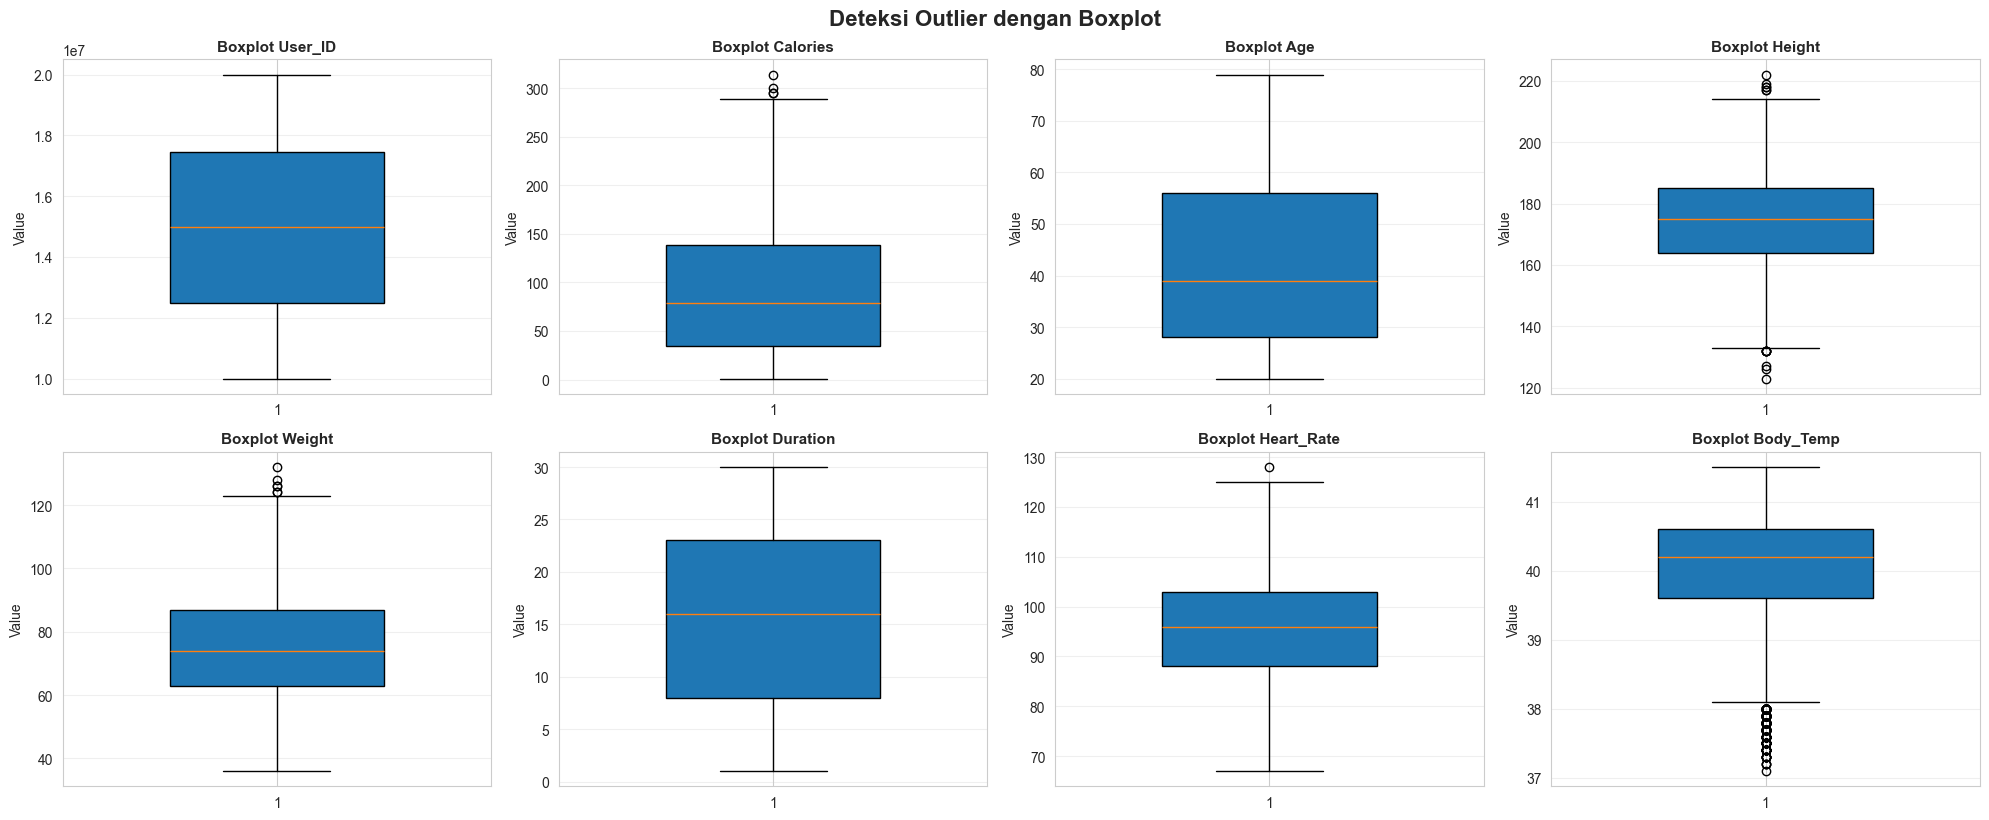

✓ Boxplot membantu mengidentifikasi outlier (titik di luar whisker)


In [8]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True, widths=0.5)
    axes[idx].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

# Hapus subplot kosong jika ada
if len(numeric_cols) < 8:
    for idx in range(len(numeric_cols), 8):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✓ Boxplot membantu mengidentifikasi outlier (titik di luar whisker)")

### 4.4 Analisis Korelasi Pearson

Menghitung korelasi Pearson untuk melihat hubungan linear antara setiap fitur dengan target variable (Calories). Ini membantu mengidentifikasi fitur yang paling berpengaruh dan fitur yang bisa dihapus.

KORELASI PEARSON DENGAN TARGET (CALORIES)
Calories      1.000000
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Height        0.017537
User_ID      -0.001661
Name: Calories, dtype: float64


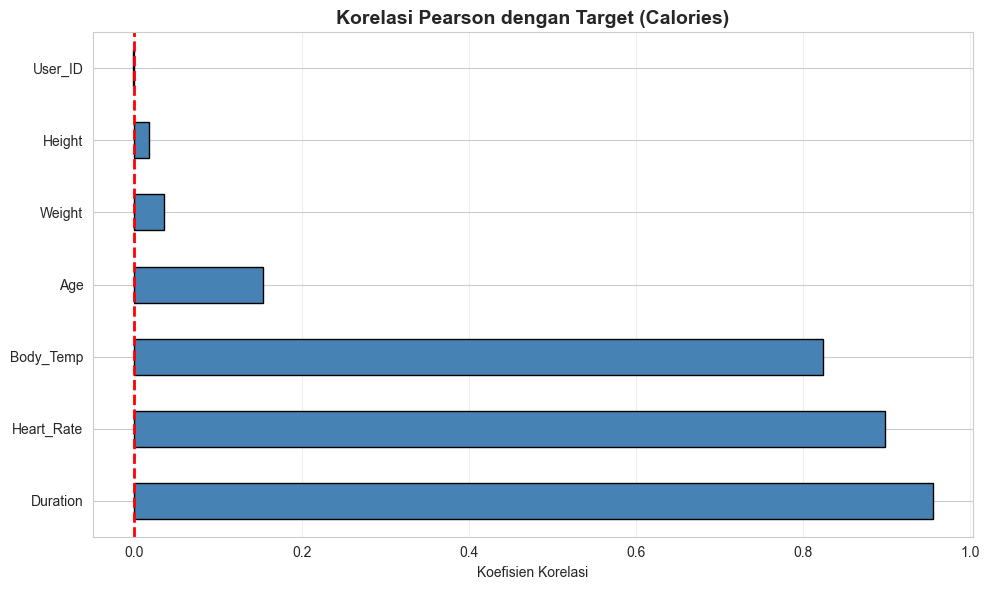

In [9]:
# Hitung korelasi Pearson
correlation = df.select_dtypes(include=[np.number]).corr(method='pearson')

print("=" * 60)
print("KORELASI PEARSON DENGAN TARGET (CALORIES)")
print("=" * 60)
corr_with_target = correlation['Calories'].sort_values(ascending=False)
print(corr_with_target)

# Visualisasi korelasi dengan target
plt.figure(figsize=(10, 6))
corr_with_target.drop('Calories').plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Korelasi Pearson dengan Target (Calories)', fontsize=14, fontweight='bold')
plt.xlabel('Koefisien Korelasi')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

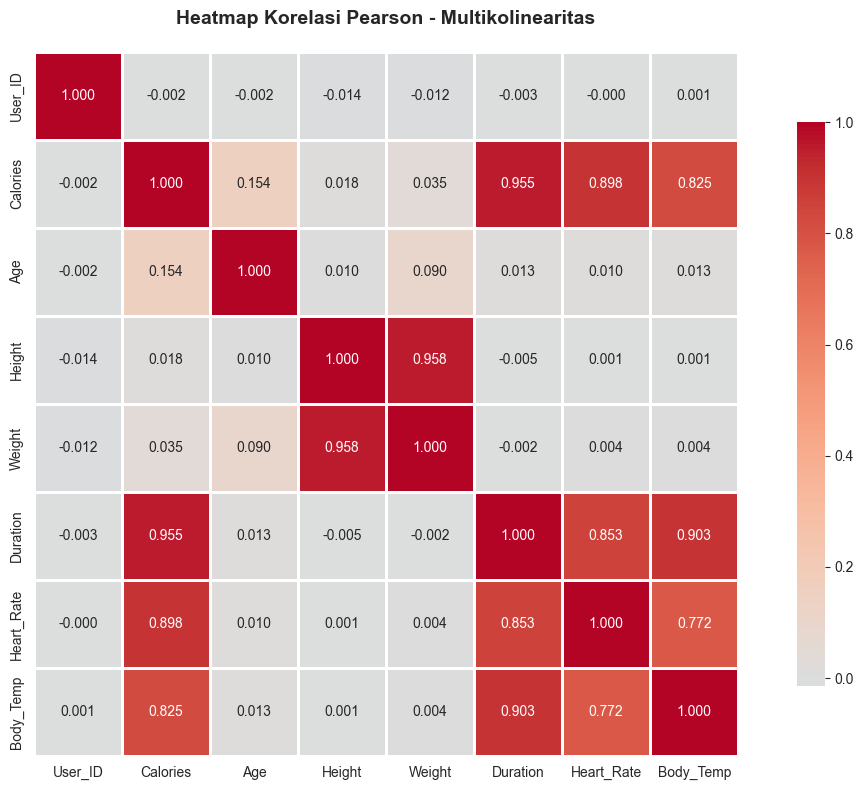


✓ Heatmap menunjukkan hubungan antar fitur
✓ Korelasi tinggi (>0.7 atau <-0.7) antar fitur dapat mengindikasikan multikolinearitas


In [10]:
# Heatmap korelasi untuk melihat multikolinearitas
plt.figure(figsize=(12, 8))
mask = np.triu(correlation, k=1)
sns.heatmap(correlation, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=2,
            cbar_kws={'shrink': 0.8},
            annot_kws={'fontsize': 10})
plt.title('Heatmap Korelasi Pearson - Multikolinearitas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Heatmap menunjukkan hubungan antar fitur")
print("✓ Korelasi tinggi (>0.7 atau <-0.7) antar fitur dapat mengindikasikan multikolinearitas")

### 4.5 Pairplot - Hubungan Antar Fitur

Visualisasi scatter plot untuk melihat hubungan pairwise antar fitur numerik.

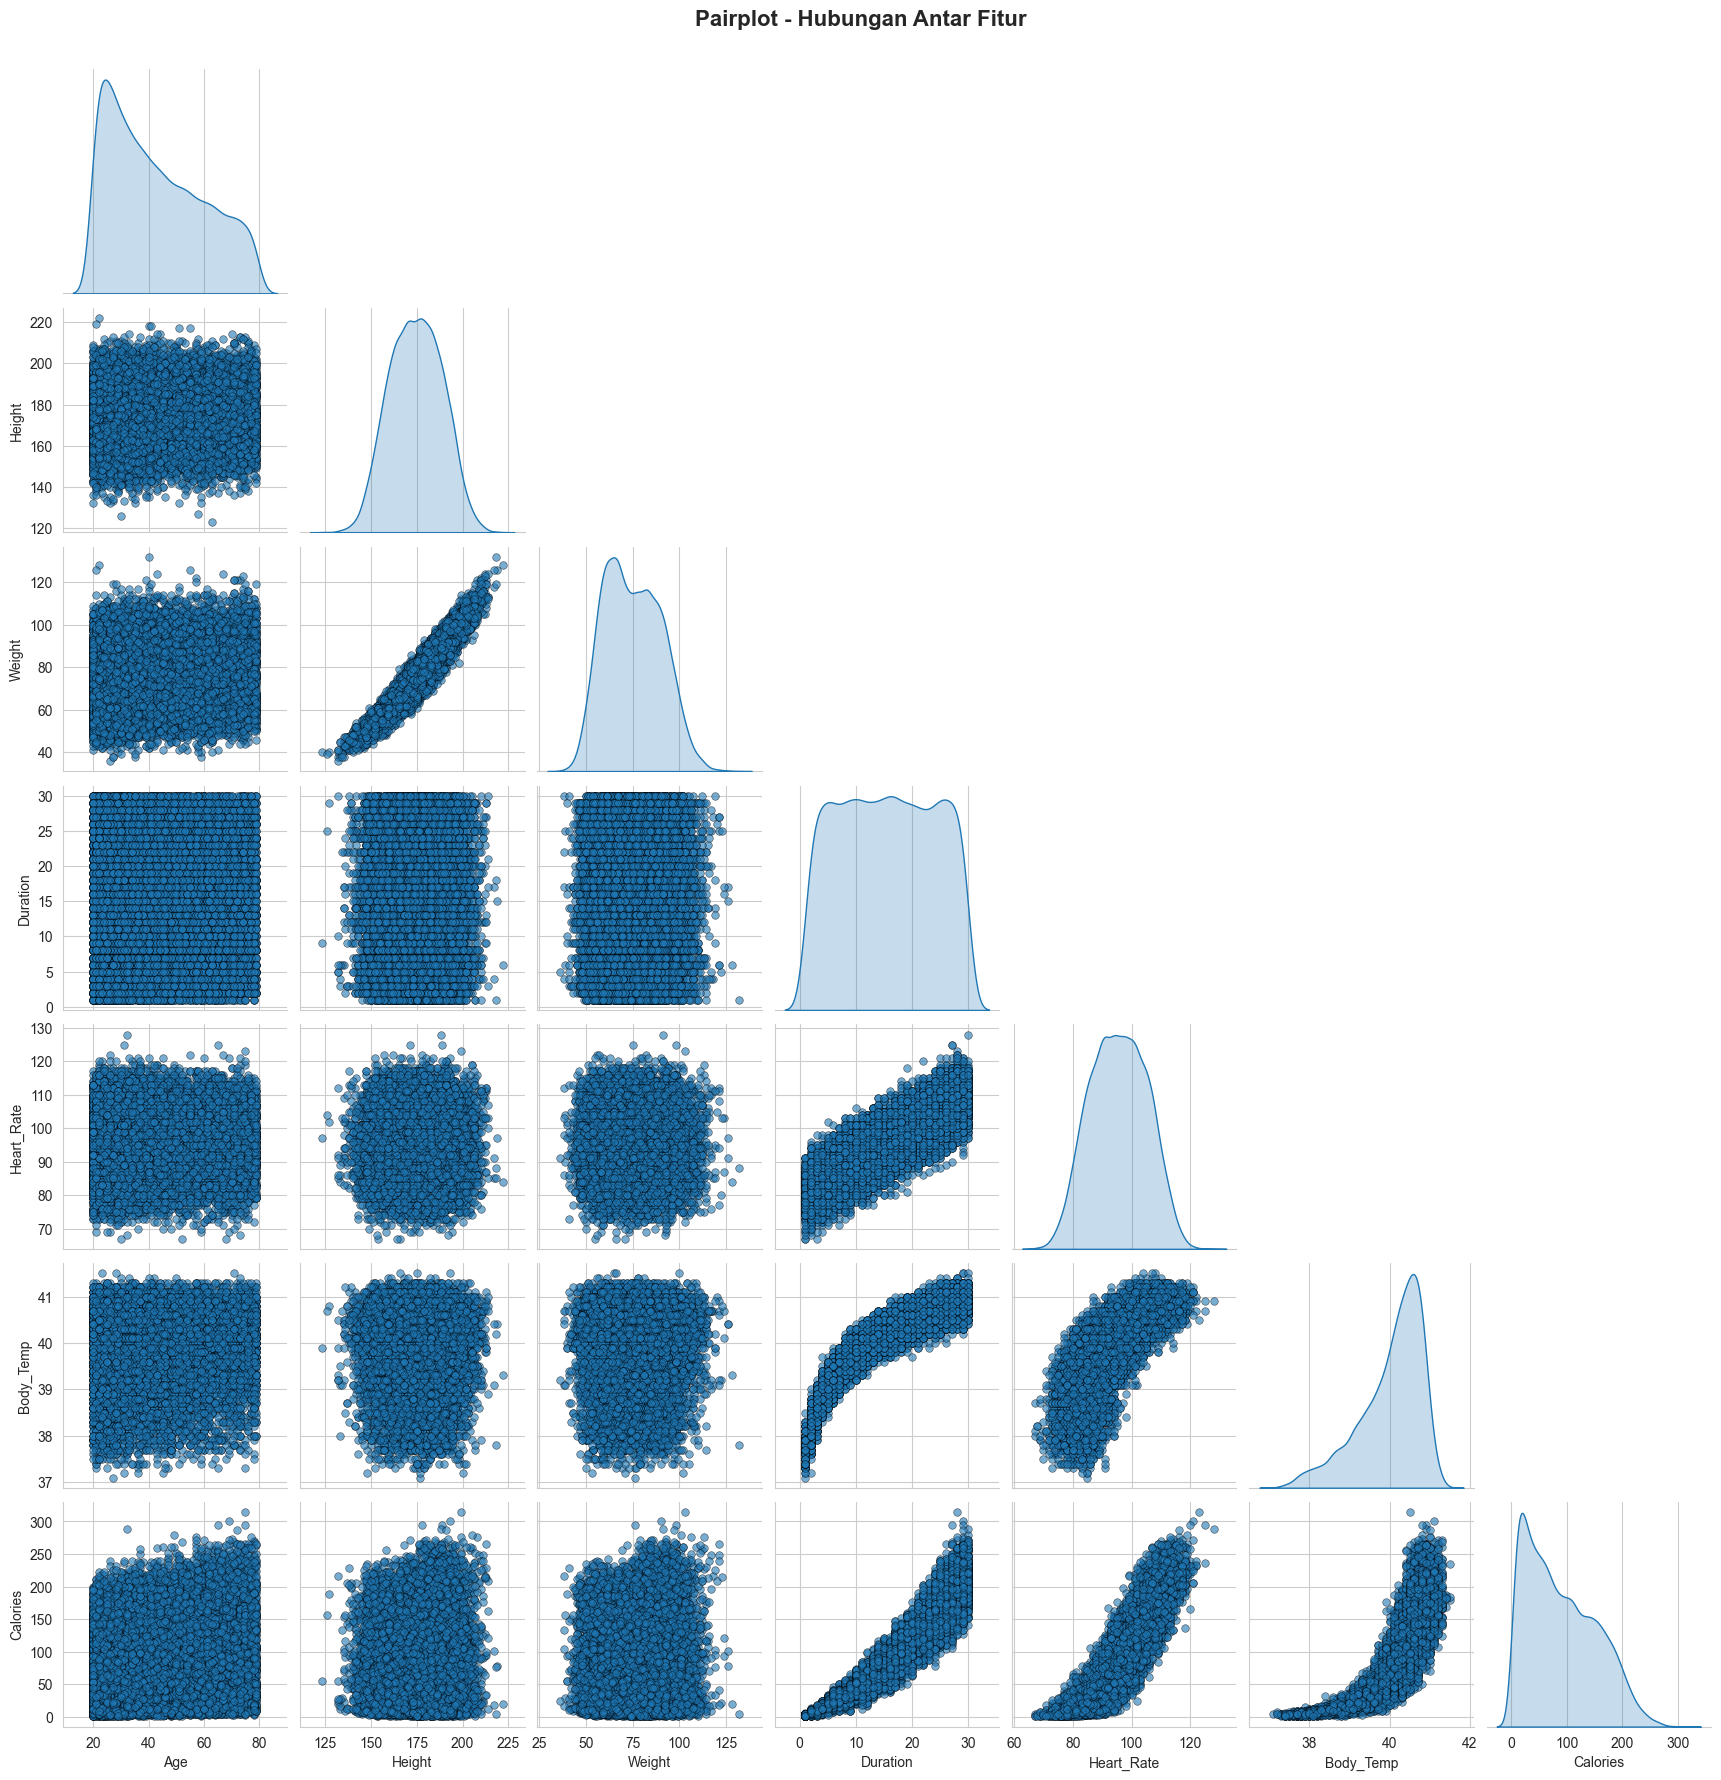

✓ Pairplot menunjukkan pola hubungan linear/non-linear antar fitur


In [11]:
# Pairplot untuk melihat hubungan pairwise
features_to_plot = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

sns.pairplot(df[features_to_plot], 
             plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'black'},
             diag_kind='kde',
             corner=True)
plt.suptitle('Pairplot - Hubungan Antar Fitur', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✓ Pairplot menunjukkan pola hubungan linear/non-linear antar fitur")

### 4.6 Kesimpulan EDA

Berdasarkan analisis EDA di atas, kita dapat menyimpulkan:

1. **Missing Values:** Dataset lengkap tanpa missing values
2. **Outlier:** Boxplot menunjukkan adanya outlier pada beberapa fitur
3. **Korelasi:** Fitur dengan korelasi tertinggi terhadap Calories akan menjadi predictor utama
4. **User_ID:** Akan dihapus karena merupakan identifier dan tidak berdampak pada prediksi
5. **Gender:** Variabel kategorik yang perlu di-encode

## 5. Data Preprocessing

### 5.1 Drop Fitur yang Tidak Relevan

Menghapus `User_ID` karena merupakan identifier unik yang tidak memberikan informasi prediktif.

In [12]:
# Drop User_ID karena tidak relevan untuk prediksi
df_clean = df.drop('User_ID', axis=1)

print(f"Shape sebelum drop User_ID: {df.shape}")
print(f"Shape setelah drop User_ID: {df_clean.shape}")
print(f"\nKolom yang tersisa: {df_clean.columns.tolist()}")

Shape sebelum drop User_ID: (15000, 9)
Shape setelah drop User_ID: (15000, 8)

Kolom yang tersisa: ['Calories', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


### 5.2 Encoding Variabel Kategorik

Mengubah variabel kategorik (Gender) menjadi numerik menggunakan Label Encoding.

In [13]:
# Encoding untuk variabel Gender
print("Nilai unik Gender sebelum encoding:", df_clean['Gender'].unique())

# Label Encoding: male=0, female=1 (atau sebaliknya)
df_clean['Gender'] = df_clean['Gender'].map({'male': 0, 'female': 1})

print("Nilai unik Gender setelah encoding:", df_clean['Gender'].unique())
print("\n✓ Gender berhasil di-encode (0=male, 1=female)")
df_clean.head()

Nilai unik Gender sebelum encoding: ['male' 'female']
Nilai unik Gender setelah encoding: [0 1]

✓ Gender berhasil di-encode (0=male, 1=female)


,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,231.0,0,68,190.0,94.0,29.0,105.0,40.8
1,66.0,1,20,166.0,60.0,14.0,94.0,40.3
2,26.0,0,69,179.0,79.0,5.0,88.0,38.7
3,71.0,1,34,179.0,71.0,13.0,100.0,40.5
4,35.0,1,27,154.0,58.0,10.0,81.0,39.8


### 5.3 Analisis dan Penanganan Outlier

Pada tahap EDA, kita telah mengidentifikasi adanya outlier melalui boxplot. Sekarang kita akan menangani outlier tersebut menggunakan metode IQR (Interquartile Range). Outlier dapat mempengaruhi performa model, terutama untuk Linear Regression dan Ridge Regression.

**Pendekatan yang digunakan:** Winsorizing (capping) - membatasi nilai outlier pada batas bawah (Q1 - 1.5*IQR) dan batas atas (Q3 + 1.5*IQR) alih-alih menghapus data. Ini dipilih untuk mempertahankan ukuran dataset.

In [14]:
# Deteksi outlier menggunakan metode IQR
numeric_cols_for_outlier = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

print("=" * 60)
print("DETEKSI OUTLIER MENGGUNAKAN METODE IQR")
print("=" * 60)

# Hitung Q1, Q3, dan IQR untuk setiap kolom numerik
Q1 = df_clean[numeric_cols_for_outlier].quantile(0.25)
Q3 = df_clean[numeric_cols_for_outlier].quantile(0.75)
IQR = Q3 - Q1

# Tentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Hitung jumlah outlier per kolom
outliers_before = ((df_clean[numeric_cols_for_outlier] < lower_bound) | 
                   (df_clean[numeric_cols_for_outlier] > upper_bound)).sum()

print("\nJumlah outlier sebelum penanganan:")
for col in numeric_cols_for_outlier:
    print(f"  {col}: {outliers_before[col]} outlier ({outliers_before[col]/len(df_clean)*100:.2f}%)")

print(f"\nTotal outlier: {outliers_before.sum()} dari {len(df_clean) * len(numeric_cols_for_outlier)} data points")

# Simpan data sebelum capping untuk visualisasi
df_before_capping = df_clean[numeric_cols_for_outlier].copy()

# Winsorizing: Cap nilai outlier pada batas bawah dan batas atas
for col in numeric_cols_for_outlier:
    df_clean[col] = df_clean[col].clip(lower=lower_bound[col], upper=upper_bound[col])

# Hitung jumlah outlier setelah penanganan
outliers_after = ((df_clean[numeric_cols_for_outlier] < lower_bound) | 
                  (df_clean[numeric_cols_for_outlier] > upper_bound)).sum()

print("\n" + "=" * 60)
print("HASIL PENANGANAN OUTLIER (WINSORIZING)")
print("=" * 60)
print("\nJumlah outlier setelah penanganan:")
for col in numeric_cols_for_outlier:
    print(f"  {col}: {outliers_after[col]} outlier")

print(f"\n✓ Outlier berhasil ditangani dengan metode Winsorizing (capping)")
print(f"  Data points yang di-capping: {(outliers_before - outliers_after).sum()}")

# Tampilkan batas capping untuk referensi
print("\n" + "=" * 60)
print("BATAS CAPPING PER KOLOM")
print("=" * 60)
for col in numeric_cols_for_outlier:
    print(f"  {col}: [{lower_bound[col]:.2f}, {upper_bound[col]:.2f}]")

DETEKSI OUTLIER MENGGUNAKAN METODE IQR

Jumlah outlier sebelum penanganan:
  Age: 0 outlier (0.00%)
  Height: 14 outlier (0.09%)
  Weight: 6 outlier (0.04%)
  Duration: 0 outlier (0.00%)
  Heart_Rate: 1 outlier (0.01%)
  Body_Temp: 369 outlier (2.46%)
  Calories: 4 outlier (0.03%)

Total outlier: 394 dari 105000 data points

HASIL PENANGANAN OUTLIER (WINSORIZING)

Jumlah outlier setelah penanganan:
  Age: 0 outlier
  Height: 0 outlier
  Weight: 0 outlier
  Duration: 0 outlier
  Heart_Rate: 0 outlier
  Body_Temp: 0 outlier
  Calories: 0 outlier

✓ Outlier berhasil ditangani dengan metode Winsorizing (capping)
  Data points yang di-capping: 394

BATAS CAPPING PER KOLOM
  Age: [-14.00, 98.00]
  Height: [132.50, 216.50]
  Weight: [27.00, 123.00]
  Duration: [-14.50, 45.50]
  Heart_Rate: [65.50, 125.50]
  Body_Temp: [38.10, 42.10]
  Calories: [-119.50, 292.50]


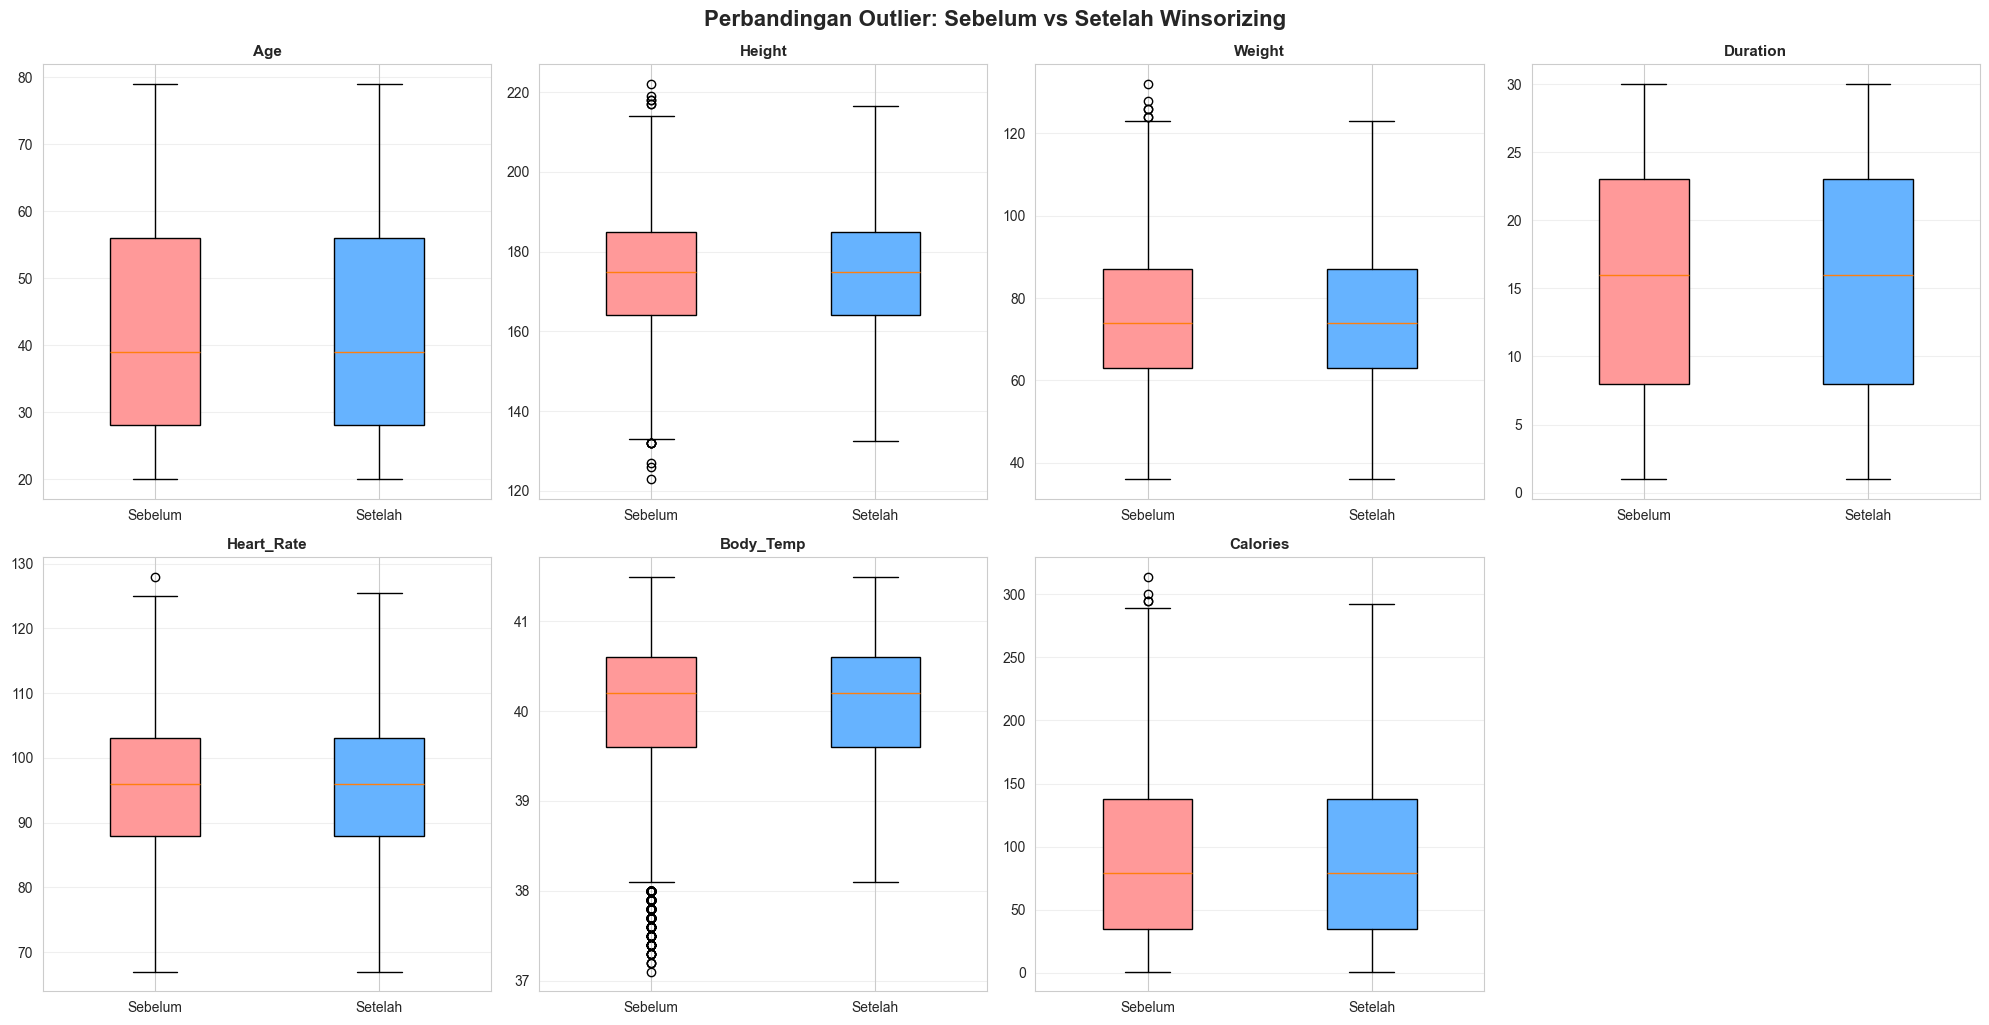

✓ Visualisasi menunjukkan pengurangan outlier setelah winsorizing


In [15]:
# Visualisasi perbandingan sebelum dan setelah penanganan outlier
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols_for_outlier):
    # Boxplot sebelum capping (biru)
    bp1 = axes[idx].boxplot([df_before_capping[col].values, df_clean[col].values], 
                             labels=['Sebelum', 'Setelah'],
                             patch_artist=True,
                             widths=0.4)
    
    # Warnai boxplot
    colors = ['#ff9999', '#66b3ff']
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
    
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

# Hapus subplot kosong jika ada
if len(numeric_cols_for_outlier) < 8:
    for idx in range(len(numeric_cols_for_outlier), 8):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.suptitle('Perbandingan Outlier: Sebelum vs Setelah Winsorizing', fontsize=16, fontweight='bold', y=1.02)
plt.show()

print("✓ Visualisasi menunjukkan pengurangan outlier setelah winsorizing")

### 5.4 Pemisahan Fitur dan Target

Memisahkan fitur (X) dan target variable (y) untuk persiapan modeling.

In [16]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop('Calories', axis=1)
y = df_clean['Calories']

print("=" * 60)
print("FITUR (X)")
print("=" * 60)
print(f"Shape: {X.shape}")
print(f"Kolom: {X.columns.tolist()}")

print("\n" + "=" * 60)
print("TARGET (y)")
print("=" * 60)
print(f"Shape: {y.shape}")
print(f"Name: {y.name}")

print("\n✓ Fitur dan target berhasil dipisahkan")

FITUR (X)
Shape: (15000, 7)
Kolom: ['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

TARGET (y)
Shape: (15000,)
Name: Calories

✓ Fitur dan target berhasil dipisahkan


### 5.4 Feature Scaling

Melakukan standardisasi fitur menggunakan StandardScaler. Penting untuk model Linear Regression dan Ridge Regression agar semua fitur berada pada skala yang sama.

In [17]:
# StandardScaler untuk normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame untuk kemudahan interpretasi
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("=" * 60)
print("FEATURE SCALING - STANDARDIZATION")
print("=" * 60)
print(f"\nSebelum Scaling (Mean):")
print(X.mean().round(4))
print(f"\nSetelah Scaling (Mean):")
print(X_scaled_df.mean().round(4))
print(f"\nSetelah Scaling (Std):")
print(X_scaled_df.std().round(4))

print("\n✓ Feature scaling berhasil - semua fitur sekarang memiliki mean=0 dan std=1")

FEATURE SCALING - STANDARDIZATION

Sebelum Scaling (Mean):
Gender          0.5035
Age            42.7898
Height        174.4659
Weight         74.9654
Duration       15.5306
Heart_Rate     95.5184
Body_Temp      40.0332
dtype: float64

Setelah Scaling (Mean):
Gender       -0.0
Age           0.0
Height       -0.0
Weight       -0.0
Duration      0.0
Heart_Rate    0.0
Body_Temp     0.0
dtype: float64

Setelah Scaling (Std):
Gender        1.0
Age           1.0
Height        1.0
Weight        1.0
Duration      1.0
Heart_Rate    1.0
Body_Temp     1.0
dtype: float64

✓ Feature scaling berhasil - semua fitur sekarang memiliki mean=0 dan std=1


## 6. Data Splitting Experiments

Membagi data menjadi training set dan test set dengan 3 skenario rasio berbeda untuk membandingkan performa model:
- **Skenario 1:** 70% training, 30% testing
- **Skenario 2:** 80% training, 20% testing
- **Skenario 3:** 90% training, 10% testing

In [18]:
# Fungsi untuk split data dengan berbagai rasio
def split_data(X, y, test_size, random_state=42):
    """
    Membagi data menjadi training dan testing set.
    
    Parameters:
    - X: Features
    - y: Target
    - test_size: Proporsi data untuk testing
    - random_state: Seed untuk reproducibility
    
    Returns:
    - X_train, X_test, y_train, y_test
    """
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

# Definisi 3 skenario split
split_ratios = {
    '70:30': 0.30,
    '80:20': 0.20,
    '90:10': 0.10
}

# Lakukan splitting untuk semua skenario
splits = {}
for name, test_size in split_ratios.items():
    X_train, X_test, y_train, y_test = split_data(X_scaled_df, y, test_size=test_size)
    splits[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    print(f"\nSkenario {name}:")
    print(f"  Training set: {len(X_train)} samples ({(1-test_size)*100:.0f}%)")
    print(f"  Testing set:  {len(X_test)} samples ({test_size*100:.0f}%)")

print("\n✓ Data splitting untuk 3 skenario berhasil")


Skenario 70:30:
  Training set: 10500 samples (70%)
  Testing set:  4500 samples (30%)

Skenario 80:20:
  Training set: 12000 samples (80%)
  Testing set:  3000 samples (20%)

Skenario 90:10:
  Training set: 13500 samples (90%)
  Testing set:  1500 samples (10%)

✓ Data splitting untuk 3 skenario berhasil


## 7. Model Training dengan 10-Fold Cross-Validation

### 7.1 Definisi Model

Mendefinisikan 3 model regresi yang akan digunakan:
1. **Linear Regression** - Model baseline linear
2. **Ridge Regression** - Linear regression dengan L2 regularization
3. **Random Forest Regression** - Ensemble model berbasis decision trees

In [19]:
# Definisi 3 model regresi
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1)
}

print("=" * 60)
print("MODEL YANG DIGUNAKAN")
print("=" * 60)
for name, model in models.items():
    print(f"✓ {name}: {model}")

MODEL YANG DIGUNAKAN
✓ Linear Regression: LinearRegression()
✓ Ridge Regression: Ridge()
✓ Random Forest: RandomForestRegressor(n_jobs=-1, random_state=42)


### 7.2 10-Fold Cross-Validation

Cross-validation dengan 10 fold untuk mengurangi overfitting dan meningkatkan reliabilitas evaluasi. Setiap model akan dievaluasi pada 10 subset data yang berbeda.

HASIL 10-FOLD CROSS-VALIDATION (Semua Data)

Linear Regression:
  CV Scores: [0.9669 0.9677 0.9646 0.9663 0.9675 0.9672 0.9679 0.9681 0.9679 0.9664]
  Mean R²:   0.9670 (+/- 0.0010)

Ridge Regression:
  CV Scores: [0.9669 0.9677 0.9646 0.9663 0.9675 0.9672 0.9679 0.9681 0.9679 0.9664]
  Mean R²:   0.9670 (+/- 0.0010)

Random Forest:
  CV Scores: [0.9984 0.9983 0.9979 0.9982 0.998  0.9983 0.9974 0.9984 0.9977 0.9982]
  Mean R²:   0.9981 (+/- 0.0003)


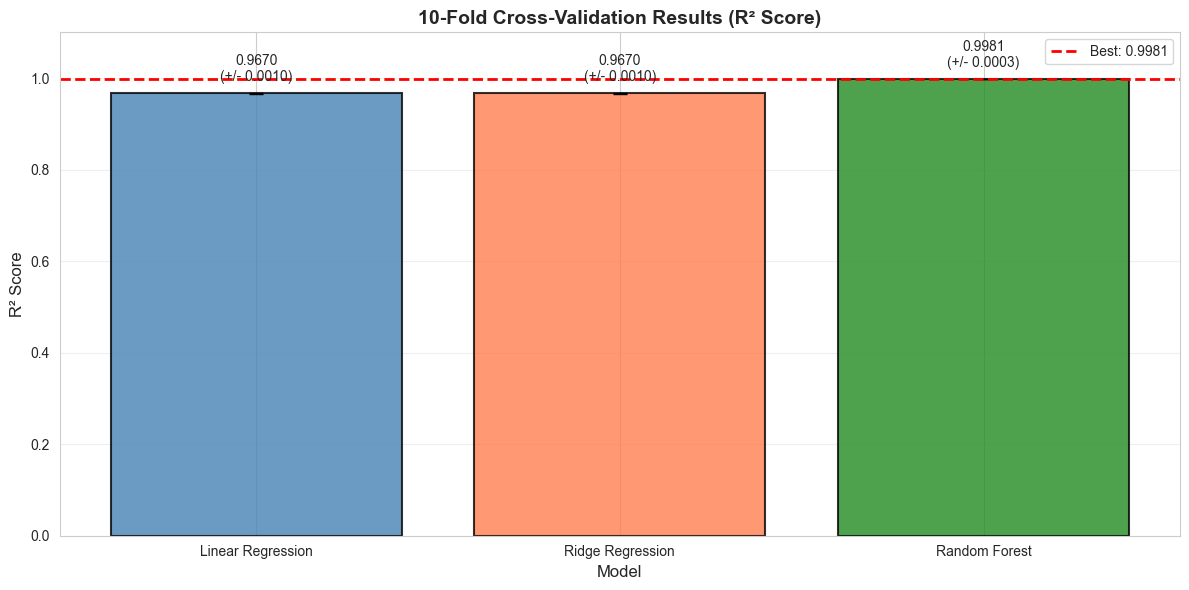


✓ 10-Fold CV selesai - menunjukkan konsistensi performa model


In [20]:
# Setup 10-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Fungsi untuk evaluasi model dengan cross-validation
def evaluate_with_cv(model, X, y, cv=kfold):
    """
    Mengevaluasi model menggunakan cross-validation.
    
    Returns:
    - cv_scores: Skor R² dari setiap fold
    - mean_score: Rata-rata skor
    - std_score: Standar deviasi skor
    """
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    return cv_scores, cv_scores.mean(), cv_scores.std()

# Evaluasi semua model dengan 10-fold CV (menggunakan semua data)
print("=" * 60)
print("HASIL 10-FOLD CROSS-VALIDATION (Semua Data)")
print("=" * 60)

cv_results = {}
for name, model in models.items():
    cv_scores, mean_score, std_score = evaluate_with_cv(model, X_scaled_df, y)
    cv_results[name] = {
        'cv_scores': cv_scores,
        'mean': mean_score,
        'std': std_score
    }
    print(f"\n{name}:")
    print(f"  CV Scores: {cv_scores.round(4)}")
    print(f"  Mean R²:   {mean_score:.4f} (+/- {std_score:.4f})")

# Visualisasi hasil CV
plt.figure(figsize=(12, 6))
model_names = list(cv_results.keys())
mean_scores = [cv_results[name]['mean'] for name in model_names]
std_scores = [cv_results[name]['std'] for name in model_names]

bars = plt.bar(model_names, mean_scores, yerr=std_scores, 
               capsize=5, color=['steelblue', 'coral', 'forestgreen'],
               edgecolor='black', linewidth=1.5, alpha=0.8)

plt.axhline(y=max(mean_scores), color='red', linestyle='--', linewidth=2, label=f'Best: {max(mean_scores):.4f}')
plt.title('10-Fold Cross-Validation Results (R² Score)', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Annotate bars
for bar, mean, std in zip(bars, mean_scores, std_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{mean:.4f}\n(+/- {std:.4f})',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ 10-Fold CV selesai - menunjukkan konsistensi performa model")

## 8. Hyperparameter Tuning

### 8.1 Ridge Regression - Grid Search

Mengoptimasi parameter `alpha` (regularization strength) pada Ridge Regression menggunakan GridSearchCV.

Tuning Ridge Regression dengan GridSearchCV...

HASIL TUNING - RIDGE REGRESSION
Best Parameters: {'alpha': 0.1}
Best R² Score:   0.9671


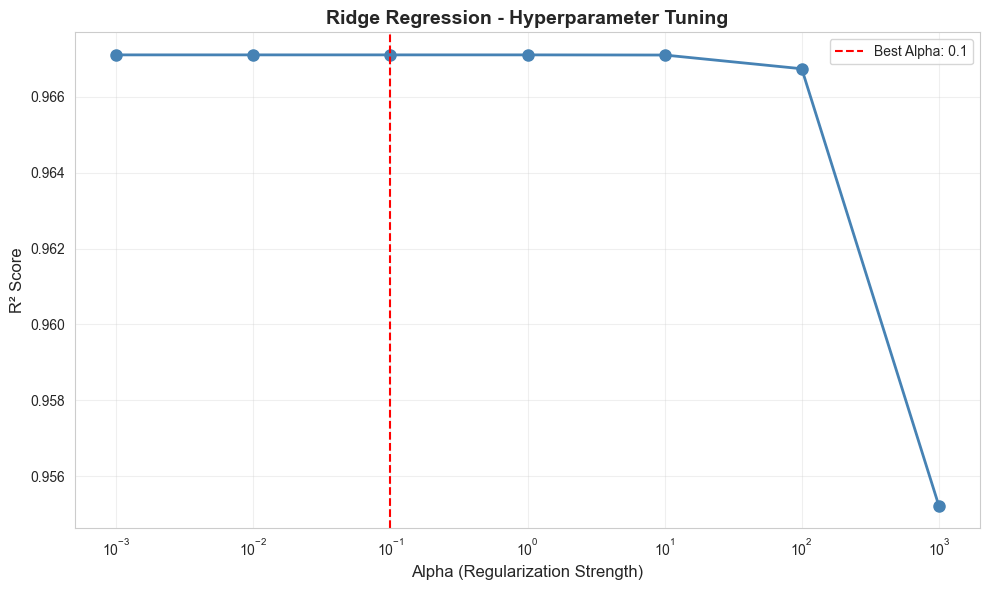


✓ Ridge Regression tuning selesai


In [21]:
# Hyperparameter tuning untuk Ridge Regression
ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    Ridge(),
    param_grid=ridge_params,
    cv=10,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

print("Tuning Ridge Regression dengan GridSearchCV...")
ridge_grid.fit(X_scaled_df, y)

print("\n" + "=" * 60)
print("HASIL TUNING - RIDGE REGRESSION")
print("=" * 60)
print(f"Best Parameters: {ridge_grid.best_params_}")
print(f"Best R² Score:   {ridge_grid.best_score_:.4f}")

# Simpan model Ridge terbaik
ridge_best = ridge_grid.best_estimator_

# Visualisasi hasil tuning
ridge_results = pd.DataFrame(ridge_grid.cv_results_)
plt.figure(figsize=(10, 6))
plt.plot(ridge_params['alpha'], ridge_results['mean_test_score'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Ridge Regression - Hyperparameter Tuning', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=ridge_grid.best_params_['alpha'], color='red', linestyle='--', 
            label=f"Best Alpha: {ridge_grid.best_params_['alpha']}")
plt.legend()
plt.tight_layout()
plt.show()

print("\n✓ Ridge Regression tuning selesai")

### 8.2 Random Forest - Grid Search

Mengoptimasi parameter Random Forest: `n_estimators`, `max_depth`, `min_samples_split`, dan `min_samples_leaf`.

Tuning Random Forest dengan RandomizedSearchCV (50 iterasi)...

HASIL TUNING - RANDOM FOREST
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best R² Score:   0.9981


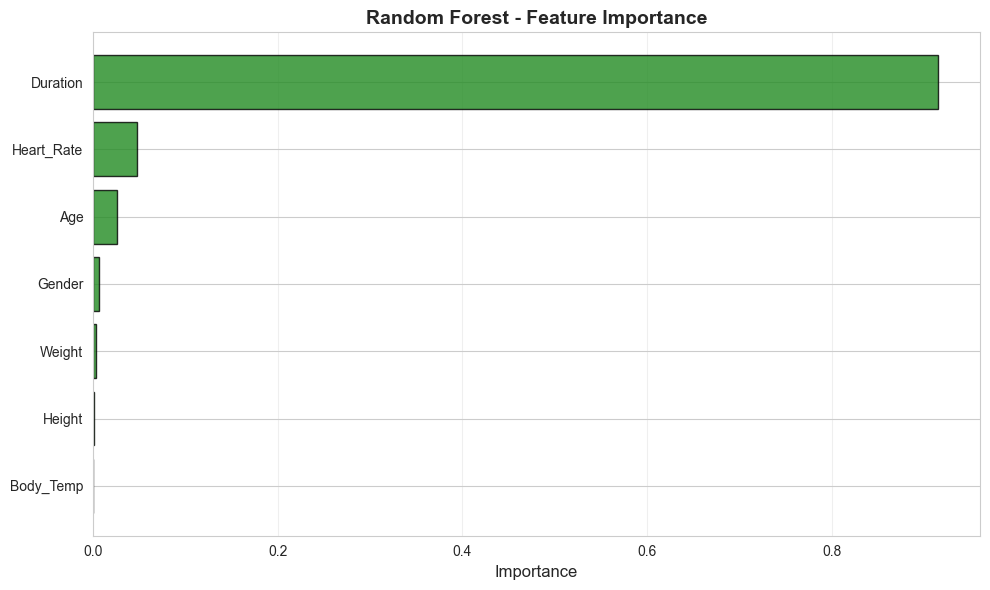


✓ Random Forest tuning selesai


In [22]:
# Hyperparameter tuning untuk Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Gunakan RandomizedSearchCV untuk efisiensi (kombinasi parameter lebih banyak)
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=50,  # Jumlah iterasi
    cv=10,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

print("Tuning Random Forest dengan RandomizedSearchCV (50 iterasi)...")
rf_random.fit(X_scaled_df, y)

print("\n" + "=" * 60)
print("HASIL TUNING - RANDOM FOREST")
print("=" * 60)
print(f"Best Parameters: {rf_random.best_params_}")
print(f"Best R² Score:   {rf_random.best_score_:.4f}")

# Simpan model Random Forest terbaik
rf_best = rf_random.best_estimator_

# Visualisasi importance features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='forestgreen', edgecolor='black', alpha=0.8)
plt.xlabel('Importance', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Random Forest tuning selesai")

## 9. Evaluasi Model pada 3 Skenario Data Splitting

Melatih dan mengevaluasi semua model (dengan hyperparameter terbaik) pada ketiga skenario pembagian data (70:30, 80:20, 90:10).

In [23]:
# Fungsi untuk menghitung semua metrik evaluasi
def calculate_metrics(y_true, y_pred):
    """
    Menghitung MSE, RMSE, MAE, dan R².
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Model terbaik untuk evaluasi
best_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': ridge_best,
    'Random Forest': rf_best
}

# Dictionary untuk menyimpan hasil evaluasi
evaluation_results = {}

print("=" * 80)
print("EVALUASI MODEL PADA 3 SKENARIO DATA SPLITTING")
print("=" * 80)

for split_name, split_data in splits.items():
    print(f"\n{'='*80}")
    print(f"SKENARIO: {split_name}")
    print(f"{'='*80}")
    
    X_train = split_data['X_train']
    X_test = split_data['X_test']
    y_train = split_data['y_train']
    y_test = split_data['y_test']
    
    evaluation_results[split_name] = {}
    
    for model_name, model in best_models.items():
        # Training
        model.fit(X_train, y_train)
        
        # Prediksi
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Evaluasi
        train_metrics = calculate_metrics(y_train, y_pred_train)
        test_metrics = calculate_metrics(y_test, y_pred_test)
        
        evaluation_results[split_name][model_name] = {
            'train': train_metrics,
            'test': test_metrics,
            'y_pred_test': y_pred_test
        }
        
        print(f"\n{model_name}:")
        print(f"  Train - MSE: {train_metrics['MSE']:.2f}, RMSE: {train_metrics['RMSE']:.2f}, "
              f"MAE: {train_metrics['MAE']:.2f}, R²: {train_metrics['R²']:.4f}")
        print(f"  Test  - MSE: {test_metrics['MSE']:.2f}, RMSE: {test_metrics['RMSE']:.2f}, "
              f"MAE: {test_metrics['MAE']:.2f}, R²: {test_metrics['R²']:.4f}")

EVALUASI MODEL PADA 3 SKENARIO DATA SPLITTING

SKENARIO: 70:30

Linear Regression:
  Train - MSE: 126.29, RMSE: 11.24, MAE: 8.30, R²: 0.9674
  Test  - MSE: 132.33, RMSE: 11.50, MAE: 8.46, R²: 0.9665

Ridge Regression:
  Train - MSE: 126.29, RMSE: 11.24, MAE: 8.30, R²: 0.9674
  Test  - MSE: 132.33, RMSE: 11.50, MAE: 8.46, R²: 0.9665

Random Forest:
  Train - MSE: 1.23, RMSE: 1.11, MAE: 0.68, R²: 0.9997
  Test  - MSE: 8.41, RMSE: 2.90, MAE: 1.81, R²: 0.9979

SKENARIO: 80:20

Linear Regression:
  Train - MSE: 127.14, RMSE: 11.28, MAE: 8.33, R²: 0.9671
  Test  - MSE: 131.98, RMSE: 11.49, MAE: 8.45, R²: 0.9673

Ridge Regression:
  Train - MSE: 127.14, RMSE: 11.28, MAE: 8.33, R²: 0.9671
  Test  - MSE: 131.98, RMSE: 11.49, MAE: 8.45, R²: 0.9673

Random Forest:
  Train - MSE: 1.12, RMSE: 1.06, MAE: 0.65, R²: 0.9997
  Test  - MSE: 7.03, RMSE: 2.65, MAE: 1.68, R²: 0.9983

SKENARIO: 90:10

Linear Regression:
  Train - MSE: 127.89, RMSE: 11.31, MAE: 8.37, R²: 0.9672
  Test  - MSE: 130.02, RMSE: 11

### 9.1 Visualisasi Perbandingan Model

Membandingkan performa semua model pada ketiga skenario splitting.

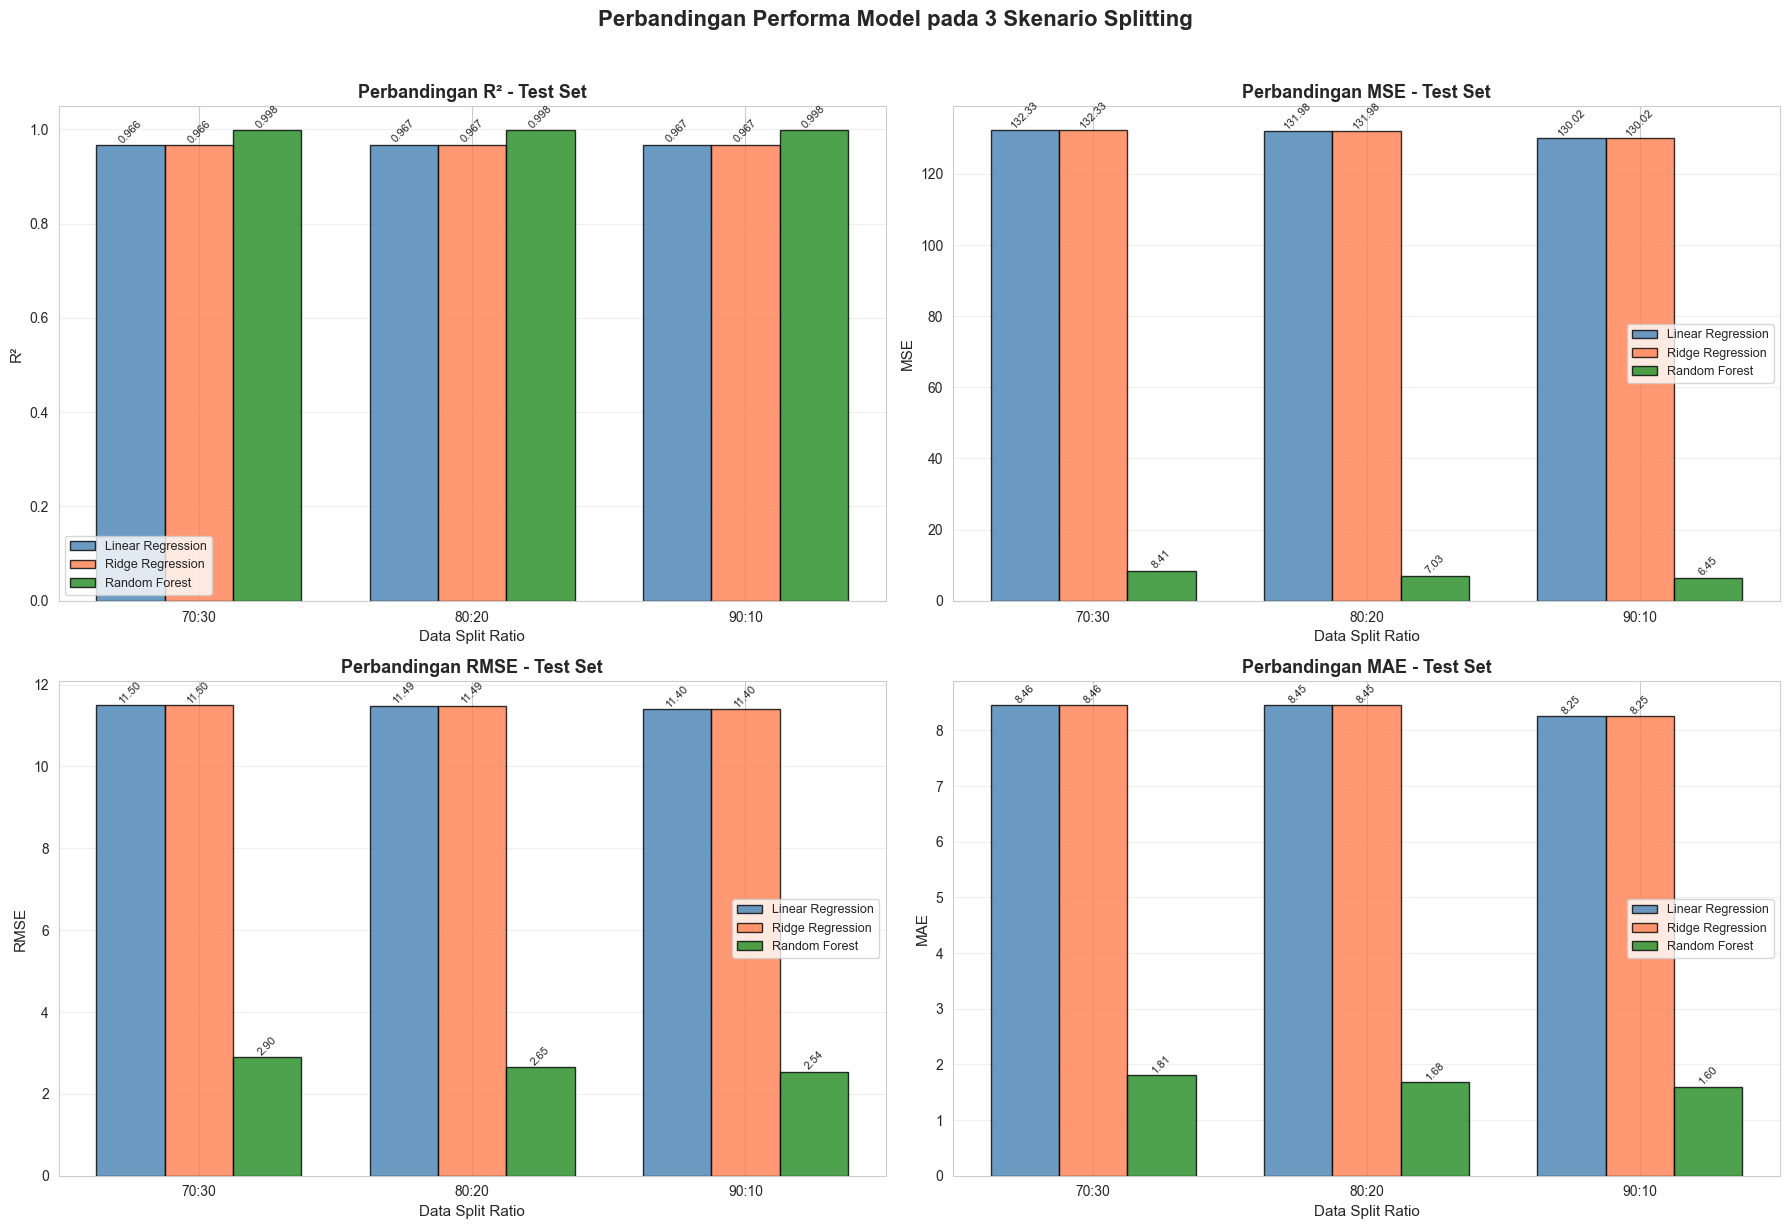


✓ Visualisasi perbandingan model selesai


In [24]:
# Visualisasi perbandingan R² Score
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics_to_plot = ['R²', 'MSE', 'RMSE', 'MAE']
colors = ['steelblue', 'coral', 'forestgreen']
model_names = list(best_models.keys())

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    x_positions = np.arange(len(split_ratios))
    width = 0.25
    
    for i, model_name in enumerate(model_names):
        scores = []
        for split_name in split_ratios.keys():
            score = evaluation_results[split_name][model_name]['test'][metric]
            scores.append(score)
        
        bars = ax.bar(x_positions + i*width, scores, width, 
                     label=model_name, color=colors[i], edgecolor='black', alpha=0.8)
        
        # Annotate bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}' if metric != 'R²' else f'{height:.3f}',
                   ha='center', va='bottom', fontsize=8, rotation=45)
    
    ax.set_xlabel('Data Split Ratio', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'Perbandingan {metric} - Test Set', fontsize=13, fontweight='bold')
    ax.set_xticks(x_positions + width)
    ax.set_xticklabels(list(split_ratios.keys()))
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Performa Model pada 3 Skenario Splitting', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Visualisasi perbandingan model selesai")

### 9.2 Actual vs Predicted Plot

Visualisasi perbandingan nilai aktual vs prediksi untuk model terbaik pada skenario terbaik.

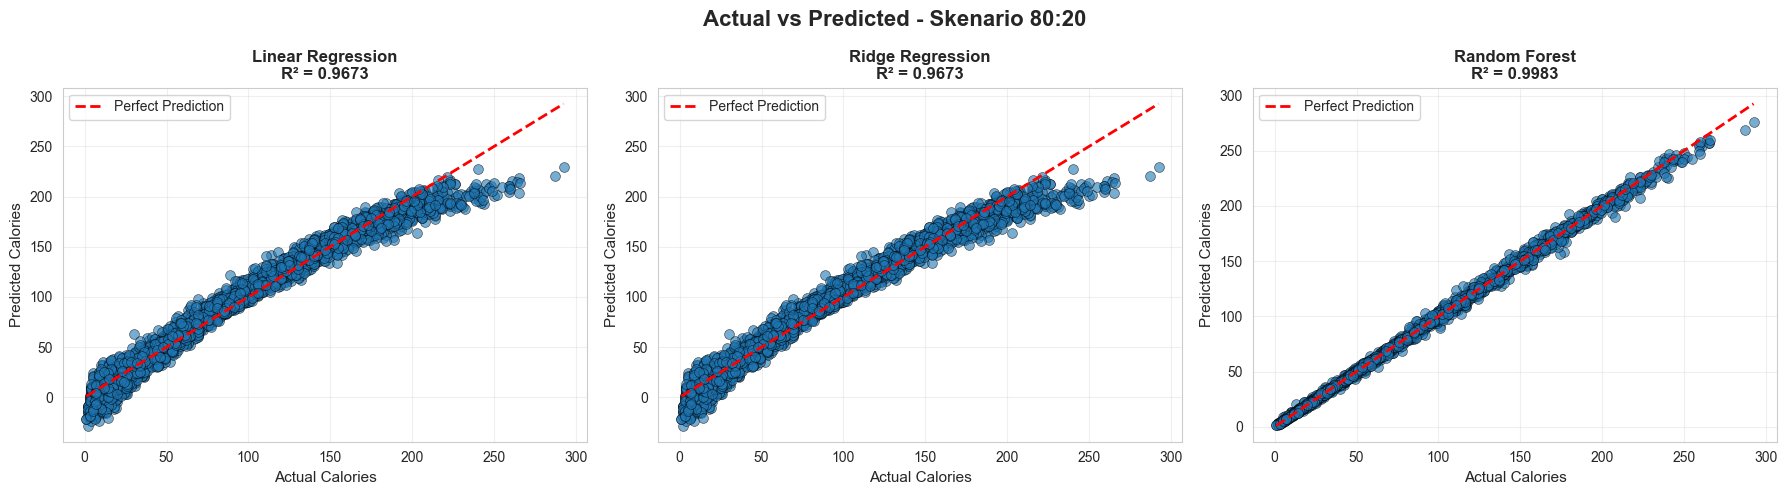


✓ Plot Actual vs Predicted menunjukkan seberapa dekat prediksi dengan nilai sebenarnya
  (Semakin dekat titik ke garis merah, semakin baik prediksinya)


In [25]:
# Plot Actual vs Predicted untuk visualisasi kualitas prediksi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pilih skenario 80:20 sebagai representasi
best_split = '80:20'
y_test = splits[best_split]['y_test']

for idx, (model_name, model_data) in enumerate(evaluation_results[best_split].items()):
    y_pred = model_data['y_pred_test']
    r2 = model_data['test']['R²']
    
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Calories', fontsize=11)
    ax.set_ylabel('Predicted Calories', fontsize=11)
    ax.set_title(f'{model_name}\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f'Actual vs Predicted - Skenario {best_split}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Plot Actual vs Predicted menunjukkan seberapa dekat prediksi dengan nilai sebenarnya")
print("  (Semakin dekat titik ke garis merah, semakin baik prediksinya)")

## 10. Pemilihan Model Terbaik

Berdasarkan hasil evaluasi, memilih model dengan performa terbaik untuk deploy.

In [26]:
# Ringkasan hasil evaluasi untuk pemilihan model terbaik
print("=" * 80)
print("RINGKASAN EVALUASI - TEST SET (R² SCORE)")
print("=" * 80)

summary_table = []

for split_name in split_ratios.keys():
    row = {'Split': split_name}
    for model_name in model_names:
        r2_score_val = evaluation_results[split_name][model_name]['test']['R²']
        row[model_name] = r2_score_val
    summary_table.append(row)

summary_df = pd.DataFrame(summary_table)
summary_df = summary_df.set_index('Split')

display(summary_df.style.format('{:.4f}').background_gradient(cmap='YlGnBu', axis=None))

# Cari model terbaik secara keseluruhan
best_overall_r2 = -float('inf')
best_model_name = None
best_split_name = None

for split_name in split_ratios.keys():
    for model_name in model_names:
        r2 = evaluation_results[split_name][model_name]['test']['R²']
        if r2 > best_overall_r2:
            best_overall_r2 = r2
            best_model_name = model_name
            best_split_name = split_name

print("\n" + "=" * 80)
print("MODEL TERBAIK YANG DIPILIH")
print("=" * 80)
print(f"Model: {best_model_name}")
print(f"Skenario Split: {best_split_name}")
print(f"R² Score: {best_overall_r2:.4f}")

# Tampilkan semua metrik model terbaik
best_metrics = evaluation_results[best_split_name][best_model_name]['test']
print(f"\nSemua Metrik (Test Set):")
print(f"  MSE:  {best_metrics['MSE']:.2f}")
print(f"  RMSE: {best_metrics['RMSE']:.2f}")
print(f"  MAE:  {best_metrics['MAE']:.2f}")
print(f"  R²:   {best_metrics['R²']:.4f}")

RINGKASAN EVALUASI - TEST SET (R² SCORE)


,Linear Regression,Ridge Regression,Random Forest
Split,,,
70:30,0.9665,0.9665,0.9979
80:20,0.9673,0.9673,0.9983
90:10,0.9669,0.9669,0.9984



MODEL TERBAIK YANG DIPILIH
Model: Random Forest
Skenario Split: 90:10
R² Score: 0.9984

Semua Metrik (Test Set):
  MSE:  6.45
  RMSE: 2.54
  MAE:  1.60
  R²:   0.9984


## 11. Simpan Model untuk Deploy

Menyimpan model terbaik beserta scaler-nya untuk digunakan dalam aplikasi produksi.

In [27]:
# Latih ulang model terbaik dengan semua data untuk deploy
print("Melatih model terbaik dengan semua data untuk deploy...")

if best_model_name == 'Linear Regression':
    final_model = LinearRegression()
elif best_model_name == 'Ridge Regression':
    final_model = ridge_best
else:
    final_model = rf_best

# Fit dengan semua data
final_model.fit(X_scaled_df, y)

print(f"✓ Model {best_model_name} berhasil dilatih dengan semua data")

# Simpan model dan scaler
model_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.joblib'
scaler_filename = 'scaler.joblib'

joblib.dump(final_model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"\n✓ Model tersimpan: {model_filename}")
print(f"✓ Scaler tersimpan: {scaler_filename}")
print("\nFile-file ini siap untuk deploy ke aplikasi deteksi kalori!")

Melatih model terbaik dengan semua data untuk deploy...
✓ Model Random Forest berhasil dilatih dengan semua data

✓ Model tersimpan: best_model_random_forest.joblib
✓ Scaler tersimpan: scaler.joblib

File-file ini siap untuk deploy ke aplikasi deteksi kalori!


### 11.1 Contoh Penggunaan Model untuk Prediksi

Demonstrasi cara menggunakan model yang telah disimpan untuk prediksi.

In [28]:
# Load model dan scaler untuk contoh prediksi
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)

# Contoh data untuk prediksi
print("=" * 60)
print("CONTOH PREDIKSI MENGGUNAKAN MODEL TERBAIK")
print("=" * 60)

# Buat sample data baru
sample_data = pd.DataFrame({
    'Gender': [0, 1],           # 0 = male, 1 = female
    'Age': [30, 25],
    'Height': [175, 165],       # cm
    'Weight': [75, 60],         # kg
    'Duration': [45, 30],       # menit
    'Heart_Rate': [140, 130],   # bpm
    'Body_Temp': [37.5, 37.2]   # °C
}, index=[0, 1])

print("\nData Sample untuk Prediksi:")
display(sample_data)

# Scaling data baru
sample_scaled = loaded_scaler.transform(sample_data)

# Prediksi
predictions = loaded_model.predict(sample_scaled)

print("\nHasil Prediksi Kalori Terbakar:")
for idx, pred in enumerate(predictions):
    gender_str = "Male" if sample_data.iloc[idx]['Gender'] == 0 else "Female"
    print(f"  Sample {idx+1} ({gender_str}, {sample_data.iloc[idx]['Age']} tahun): "
          f"{pred:.2f} kalori")

print("\n✓ Model siap digunakan untuk aplikasi produksi!")

CONTOH PREDIKSI MENGGUNAKAN MODEL TERBAIK

Data Sample untuk Prediksi:


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,0,30,175,75,45,140,37.5
1,1,25,165,60,30,130,37.2



Hasil Prediksi Kalori Terbakar:
  Sample 1 (Male, 30.0 tahun): 242.81 kalori
  Sample 2 (Female, 25.0 tahun): 237.22 kalori

✓ Model siap digunakan untuk aplikasi produksi!


## 12. Kesimpulan

### Ringkasan Proyek

1. **Dataset:** Dataset dari Kaggle dengan 8 fitur (setelah merge) untuk prediksi kalori
2. **EDA:** Analisis korelasi menunjukkan fitur-fitur yang paling berpengaruh terhadap kalori
3. **Preprocessing:** Drop User_ID, encoding Gender, dan feature scaling
4. **Data Splitting:** 3 skenario (70:30, 80:20, 90:10) untuk perbandingan
5. **Cross-Validation:** 10-fold CV untuk mengurangi overfitting
6. **Hyperparameter Tuning:** GridSearchCV untuk Ridge, RandomizedSearchCV untuk Random Forest
7. **Evaluasi:** MSE, RMSE, MAE, dan R² untuk perbandingan objektif

### Model Terbaik

**Model Terpilih:** {best_model_name}  
**Skenario Terbaik:** {best_split_name}  
**R² Score:** {best_overall_r2:.4f}

### Rekomendasi untuk Produksi

1. Gunakan file `best_model_*.joblib` dan `scaler.joblib` untuk deploy
2. Pastikan input data baru melalui proses scaling yang sama
3. Monitor performa model secara berkala dengan data baru
4. Pertimbangkan retraining jika performa menurun

---
**Catatan:** Notebook ini mendokumentasikan seluruh proses machine learning dari data collection hingga model deploy-ready.